In [ ]:
# ============================================================
# BLOCK 1: Install Dependencies
# ============================================================
%pip install transformers datasets scikit-learn seaborn matplotlib torch -q

In [ ]:
# ============================================================
# BLOCK 2: Imports
# ============================================================
import os
import random
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import seaborn as sns
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoModel, BertTokenizer, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, f1_score
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# ============================================================
# Load Dataset using KaggleHub (FIXED)
# ============================================================

%pip install -q kagglehub

import kagglehub
import pandas as pd
import os

# Download dataset
path = kagglehub.dataset_download("zara2099/english-translation-error-detection-dataset")

print("Path to dataset files:", path)

# List files
files = os.listdir(path)
print("Files:", files)

# Load CSV
csv_file = [f for f in files if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join(path, csv_file))

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

100%|██████████| 9.58k/9.58k [00:00<00:00, 18.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/zara2099/english-translation-error-detection-dataset/versions/1
Files: ['english_translation_error_dataset.csv']
Shape: (1000, 10)
Columns: ['ID', 'Original_Text', 'Translated_Text', 'Tokenized_Text', 'POS_Tags', 'Error_Flag', 'Error_Type', 'Confidence_Score', 'Detected_Error_Word', 'Correction_Suggestion']


,ID,Original_Text,Translated_Text,Tokenized_Text,POS_Tags,Error_Flag,Error_Type,Confidence_Score,Detected_Error_Word,Correction_Suggestion
0,1,The conference was attended by many experts in...,The conference was attended by many experts in...,The conference was attended by many experts in...,The/DT conference/NN was/VBD attended/VBN by/I...,0,NaN,0.85,NaN,NaN
1,2,Machine learning has revolutionized language t...,Machine learning has revolutionized language t...,Machine learning has revolutionized language t...,Machine/NN learning/NN has/VBZ revolutionized/...,0,NaN,0.80,NaN,NaN
2,3,She loves reading books on artificial intellig...,She loves reading books on artificial intellig...,She loves reading books on artificial intellig...,She/PRP loves/VBZ reading/VBG books/NNS on/IN ...,0,NaN,0.81,NaN,NaN
3,4,He quickly finished his homework before dinner.,He quickly finished his homework before dinner.,He quickly finished his homework before dinner .,He/PRP quickly/RB finished/VBD his/PRP$ homewo...,0,NaN,0.95,NaN,NaN
4,5,Our team developed a new model for speech reco...,Our team developed a new model for speech reco...,Our team developed a new model for speech reco...,Our/PRP$ team/NN developed/VBD a/DT new/JJ mod...,0,NaN,0.96,NaN,NaN


In [ ]:
# ============================================================
# BLOCK 4: Prepare Labels, Hard Negatives, and Data Splits
# ============================================================

TEXT_COLUMN = "Translated_Text"
LABEL_COLUMN = "Error_Flag"

df = df[[TEXT_COLUMN, LABEL_COLUMN]].dropna().copy()

# Ensure labels are integer binary
df[LABEL_COLUMN] = df[LABEL_COLUMN].astype(int)

def create_hard_negative(sentence: str) -> str:
    words = str(sentence).split()
    if len(words) < 3:
        return str(sentence)

    idx = random.randint(0, len(words) - 1)
    replacements = ["park", "car", "dog", "food", "city"]

    # Prevent no-op replacements where possible
    original = words[idx]
    candidates = [w for w in replacements if w.lower() != original.lower()]
    words[idx] = random.choice(candidates) if candidates else random.choice(replacements)
    return " ".join(words)

# CCCL innovation: generate hard negatives per sentence
df["hard_negative"] = df[TEXT_COLUMN].apply(create_hard_negative)

texts = df[TEXT_COLUMN].tolist()
negatives = df["hard_negative"].tolist()
labels = df[LABEL_COLUMN].tolist()

# 80/10/10 split while preserving text-negative pairing
X_train, X_temp, N_train, N_temp, y_train, y_temp = train_test_split(
    texts, negatives, labels, test_size=0.2, stratify=labels, random_state=SEED
)
X_val, X_test, N_val, N_test, y_val, y_test = train_test_split(
    X_temp, N_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print("Sample pair:")
print("  Anchor :", X_train[0])
print("  HardNeg:", N_train[0])

Train: 800 | Val: 100 | Test: 100


In [ ]:
# ============================================================
# BLOCK 5: Tokenizer & Contrastive Dataset Class
# ============================================================
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

class ContrastiveDataset(Dataset):
    def __init__(self, sentences, negatives, labels, tokenizer, max_length=128):
        self.sentences = sentences
        self.negatives = negatives
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        s1 = str(self.sentences[idx])
        s2 = str(self.negatives[idx])

        enc1 = self.tokenizer(
            s1,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        enc2 = self.tokenizer(
            s2,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return {
            "input_ids_1": enc1["input_ids"].squeeze(0),
            "attention_mask_1": enc1["attention_mask"].squeeze(0),
            "input_ids_2": enc2["input_ids"].squeeze(0),
            "attention_mask_2": enc2["attention_mask"].squeeze(0),
            "label": torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Create datasets
train_dataset = ContrastiveDataset(X_train, N_train, y_train, tokenizer)
val_dataset   = ContrastiveDataset(X_val,   N_val,   y_val,   tokenizer)
test_dataset  = ContrastiveDataset(X_test,  N_test,  y_test,  tokenizer)

# Create dataloaders
BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print("Contrastive dataloaders ready ✅")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Dataloaders ready ✅


In [ ]:
# ============================================================
# BLOCK 6: BertWithContrastive (Classification + Embedding Output)
# ============================================================
class BertWithContrastive(nn.Module):
    def __init__(self, model_name="bert-base-uncased", num_labels=2):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size
        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(cls)
        return logits, cls

model = BertWithContrastive("bert-base-uncased", num_labels=2).to(device)
print("BERT contrastive model loaded ✅")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT model loaded ✅


In [7]:
# ============================================================
# BLOCK 7: Optimizer & Scheduler
# ============================================================
EPOCHS = 5
LEARNING_RATE = 2e-5

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"Total steps: {total_steps} | Warmup steps: {warmup_steps}")

Total steps: 250 | Warmup steps: 25


In [ ]:
# ============================================================
# BLOCK 8: CCCL Training Loop (Confidence-Calibrated Contrastive Learning)
# ============================================================
def contrastive_loss(emb1, emb2, temperature=0.5):
    emb1 = F.normalize(emb1, dim=1)
    emb2 = F.normalize(emb2, dim=1)

    similarity = torch.matmul(emb1, emb2.T) / temperature
    labels = torch.arange(emb1.size(0), device=emb1.device)
    return F.cross_entropy(similarity, labels)

def confidence_weighted_loss(logits, labels):
    probs = torch.softmax(logits, dim=1)
    confidence, _ = torch.max(probs, dim=1)
    ce_loss = F.cross_entropy(logits, labels, reduction="none")
    weighted_loss = (1 - confidence) * ce_loss
    return weighted_loss.mean()

best_val_f1 = 0
patience = 2
patience_counter = 0
best_model_path = "best_bert_cccl_model.pt"
ALPHA_CONTRAST = 0.3

for epoch in range(EPOCHS):
    # --- TRAIN ---
    model.train()
    total_train_loss = 0.0
    total_train_cls = 0.0
    total_train_contrast = 0.0

    for batch in train_loader:
        input_ids_1 = batch["input_ids_1"].to(device)
        attention_mask_1 = batch["attention_mask_1"].to(device)
        input_ids_2 = batch["input_ids_2"].to(device)
        attention_mask_2 = batch["attention_mask_2"].to(device)
        labels_batch = batch["label"].to(device)

        optimizer.zero_grad()

        logits1, emb1 = model(input_ids_1, attention_mask_1)
        _, emb2 = model(input_ids_2, attention_mask_2)

        loss_cls = confidence_weighted_loss(logits1, labels_batch)
        loss_contrast = contrastive_loss(emb1, emb2)
        loss = loss_cls + ALPHA_CONTRAST * loss_contrast

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_train_loss += loss.item()
        total_train_cls += loss_cls.item()
        total_train_contrast += loss_contrast.item()

    avg_train_loss = total_train_loss / len(train_loader)
    avg_train_cls = total_train_cls / len(train_loader)
    avg_train_contrast = total_train_contrast / len(train_loader)

    # --- VALIDATE (classification branch) ---
    model.eval()
    val_preds, val_labels = [], []
    total_val_loss = 0.0

    with torch.no_grad():
        for batch in val_loader:
            input_ids_1 = batch["input_ids_1"].to(device)
            attention_mask_1 = batch["attention_mask_1"].to(device)
            labels_batch = batch["label"].to(device)

            logits, _ = model(input_ids_1, attention_mask_1)
            val_loss = F.cross_entropy(logits, labels_batch)
            total_val_loss += val_loss.item()

            preds = torch.argmax(logits, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels_batch.cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)
    val_f1 = f1_score(val_labels, val_preds, average="weighted")

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {avg_train_loss:.4f} (cls={avg_train_cls:.4f}, ctr={avg_train_contrast:.4f}) | "
        f"Val Loss: {avg_val_loss:.4f} | Val F1: {val_f1:.4f}"
    )

    # Early stopping
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"  ✅ Best CCCL model saved (F1: {best_val_f1:.4f})")
    else:
        patience_counter += 1
        print(f"  ⚠️ No improvement ({patience_counter}/{patience})")
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

# Load best weights if available
if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    model.to(device)
    model.eval()
    print(f"Loaded best checkpoint: {best_model_path}")

Epoch 1/5 | Train Loss: 0.3455 | Val Loss: 0.1532 | Val F1: 0.9328
  ✅ Best model saved (F1: 0.9328)
Epoch 2/5 | Train Loss: 0.0390 | Val Loss: 0.0027 | Val F1: 1.0000
  ✅ Best model saved (F1: 1.0000)
Epoch 3/5 | Train Loss: 0.0022 | Val Loss: 0.0011 | Val F1: 1.0000
  ⚠️ No improvement (1/2)
Epoch 4/5 | Train Loss: 0.0013 | Val Loss: 0.0008 | Val F1: 1.0000
  ⚠️ No improvement (2/2)
Early stopping triggered.


In [ ]:
# ============================================================
# BLOCK 10: Inference Pipeline — predict any sentence
# ============================================================
def predict(sentence: str):
    model.eval()
    encoding = tokenizer(
        sentence,
        max_length=128,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )
    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():
        logits, _ = model(input_ids, attention_mask)
        probs = torch.softmax(logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred].item() * 100

    label = "Semantic Error" if pred == 1 else "No Error"
    print(f"Sentence  : {sentence}")
    print(f"Prediction: {label} ({confidence:.2f}% confidence)")
    print("-" * 60)

# Test sentences
test_sentences = [
    "The doctor gave the patient a prescription.",
    "She borrowed the book and returned it next week.",
    "He sold his car and then drove it to work.",
    "The fire was put out before it started.",
    "They finished the project after it was submitted."
]

print("=" * 60)
print("INFERENCE RESULTS")
print("=" * 60)
for s in test_sentences:
    predict(s)

INFERENCE RESULTS
Sentence  : The doctor gave the patient a prescription.
Prediction: 🟢 No Error (99.71% confidence)
------------------------------------------------------------
Sentence  : She borrowed the book and returned it next week.
Prediction: 🟢 No Error (99.77% confidence)
------------------------------------------------------------
Sentence  : He sold his car and then drove it to work.
Prediction: 🟢 No Error (99.68% confidence)
------------------------------------------------------------
Sentence  : The fire was put out before it started.
Prediction: 🟢 No Error (99.67% confidence)
------------------------------------------------------------
Sentence  : They finished the project after it was submitted.
Prediction: 🟢 No Error (99.76% confidence)
------------------------------------------------------------


In [ ]:
# ============================================================
# BLOCK: Load Real Dataset from HuggingFace (CoLA)
# ============================================================

%pip install datasets -q

from datasets import load_dataset
import pandas as pd

# Load dataset
dataset = load_dataset("glue", "cola")

# Convert validation split to DataFrame (for testing)
df_test = pd.DataFrame(dataset["validation"])

# Rename columns to match your format
df_test = df_test.rename(columns={
    "sentence": "Translated_Text",
    "label": "Error_Flag"
})

# IMPORTANT:
# In CoLA:
# label = 1 -> Correct sentence
# label = 0 -> Incorrect sentence
# We invert it to match your dataset:
df_test["Error_Flag"] = 1 - df_test["Error_Flag"]

# Keep only required columns
df_test = df_test[["Translated_Text", "Error_Flag"]]

# Show info
print(f"Dataset shape: {df_test.shape}")
print(f"\nClass distribution:\n{df_test['Error_Flag'].value_counts()}")

df_test.head(10)

README.md: 0.00B [00:00, ?B/s]

cola/train-00000-of-00001.parquet:   0%|          | 0.00/251k [00:00<?, ?B/s]

cola/validation-00000-of-00001.parquet:   0%|          | 0.00/37.6k [00:00<?, ?B/s]

cola/test-00000-of-00001.parquet:   0%|          | 0.00/37.7k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8551 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1043 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1063 [00:00<?, ? examples/s]

Dataset shape: (1043, 2)

Class distribution:
Error_Flag
0    721
1    322
Name: count, dtype: int64


,Translated_Text,Error_Flag
0,The sailors rode the breeze clear of the rocks.,0
1,The weights made the rope stretch over the pul...,0
2,The mechanical doll wriggled itself loose.,0
3,"If you had eaten more, you would want less.",0
4,"As you eat the most, you want the least.",1
5,"The more you would want, the less you would eat.",1
6,"I demand that the more John eat, the more he p...",1
7,"Mary listens to the Grateful Dead, she gets de...",0
8,"The angrier Mary got, the more she looked at p...",0
9,"The higher the stakes, the lower his expectati...",0


In [ ]:
# ============================================================
# BLOCK 12: Evaluate Model on Manual Test Dataset
# ============================================================
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    matthews_corrcoef
)

manual_texts = df_test["Translated_Text"].tolist()
manual_labels = df_test["Error_Flag"].tolist()

# Reuse anchor sentence as its own negative for evaluation-only loader
manual_dataset = ContrastiveDataset(manual_texts, manual_texts, manual_labels, tokenizer)
manual_loader = DataLoader(manual_dataset, batch_size=16)

model.eval()
m_preds, m_labels, m_probs = [], [], []

with torch.no_grad():
    for batch in manual_loader:
        input_ids = batch["input_ids_1"].to(device)
        attention_mask = batch["attention_mask_1"].to(device)
        labels_batch = batch["label"].to(device)

        logits, _ = model(input_ids, attention_mask)
        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = torch.argmax(logits, dim=1)

        m_preds.extend(preds.cpu().numpy())
        m_labels.extend(labels_batch.cpu().numpy())
        m_probs.extend(probs.cpu().numpy())

print("=" * 55)
print("MANUAL TEST SET — CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(m_labels, m_preds, target_names=["No Error", "Error"]))

acc = accuracy_score(m_labels, m_preds)
f1_w = f1_score(m_labels, m_preds, average="weighted")
f1_m = f1_score(m_labels, m_preds, average="macro")
prec = precision_score(m_labels, m_preds, average="weighted")
rec = recall_score(m_labels, m_preds, average="weighted")
mcc = matthews_corrcoef(m_labels, m_preds)
auc = roc_auc_score(m_labels, m_probs)

print(f"Accuracy           : {acc:.4f}")
print(f"Weighted F1        : {f1_w:.4f}")
print(f"Macro F1           : {f1_m:.4f}")
print(f"Weighted Precision : {prec:.4f}")
print(f"Weighted Recall    : {rec:.4f}")
print(f"Matthews Corr Coef : {mcc:.4f}")
print(f"ROC-AUC Score      : {auc:.4f}")

MANUAL TEST SET — CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Error       0.74      0.98      0.84       721
       Error       0.81      0.22      0.34       322

    accuracy                           0.74      1043
   macro avg       0.78      0.60      0.59      1043
weighted avg       0.76      0.74      0.69      1043

Accuracy           : 0.7430
Weighted F1        : 0.6868
Macro F1           : 0.5917
Weighted Precision : 0.7605
Weighted Recall    : 0.7430
Matthews Corr Coef : 0.3278
ROC-AUC Score      : 0.7422


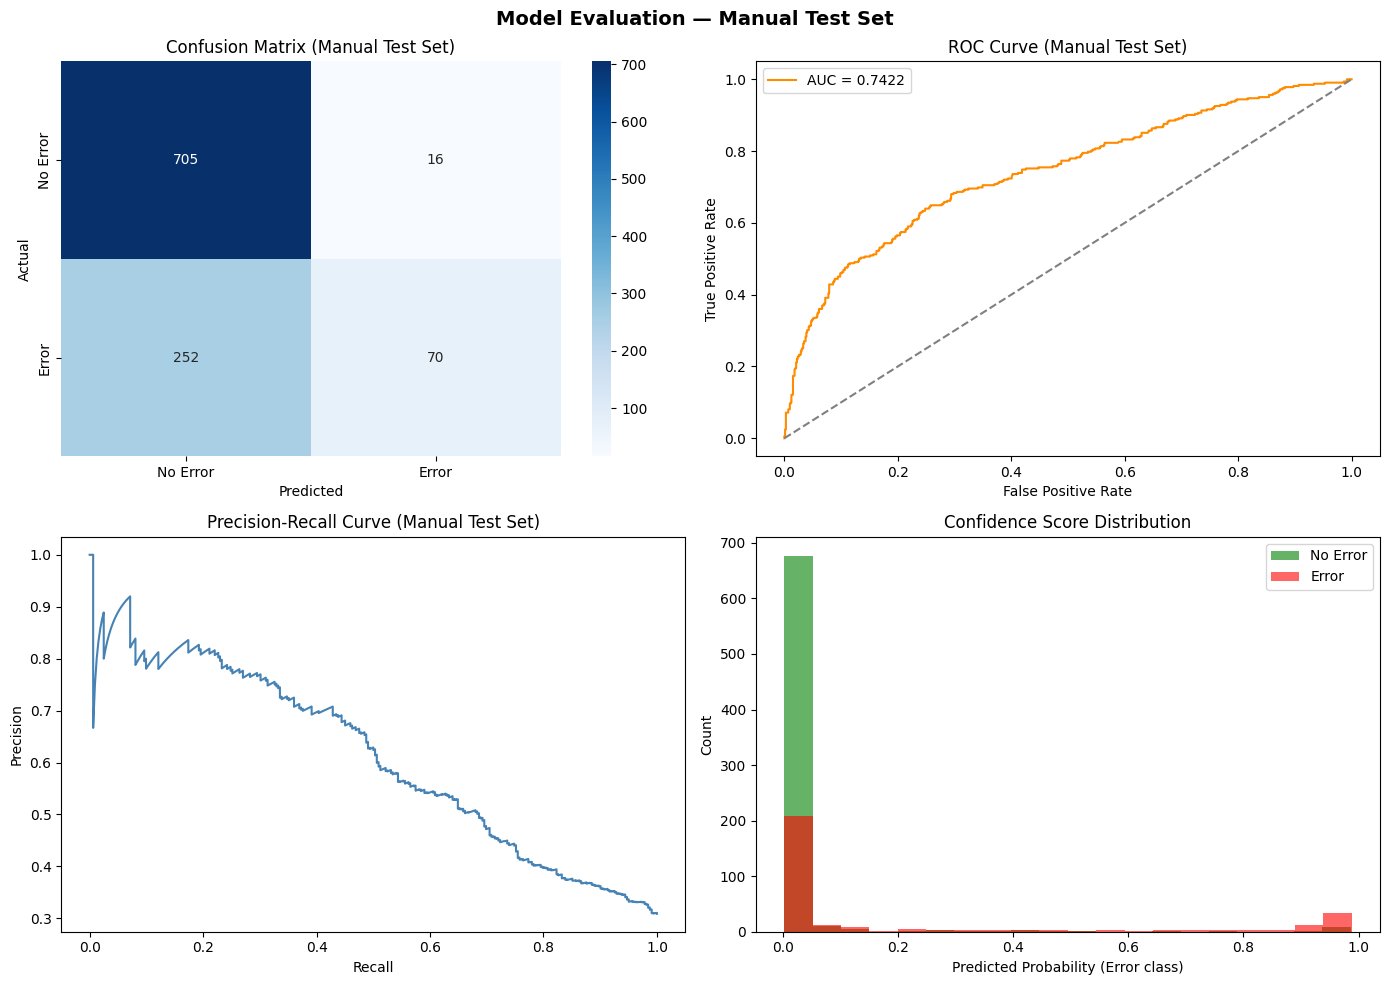

In [15]:
# ============================================================
# BLOCK 13: Extended Visualisations
# ============================================================
from sklearn.metrics import precision_recall_curve
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- 1. Confusion Matrix (Manual Test Set) ---
cm = confusion_matrix(m_labels, m_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0, 0],
            xticklabels=["No Error", "Error"],
            yticklabels=["No Error", "Error"])
axes[0, 0].set_title("Confusion Matrix (Manual Test Set)")
axes[0, 0].set_ylabel("Actual")
axes[0, 0].set_xlabel("Predicted")

# --- 2. ROC Curve ---
fpr, tpr, _ = roc_curve(m_labels, m_probs)
axes[0, 1].plot(fpr, tpr, color="darkorange", label=f"AUC = {auc:.4f}")
axes[0, 1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0, 1].set_xlabel("False Positive Rate")
axes[0, 1].set_ylabel("True Positive Rate")
axes[0, 1].set_title("ROC Curve (Manual Test Set)")
axes[0, 1].legend()

# --- 3. Precision-Recall Curve ---
precision_vals, recall_vals, _ = precision_recall_curve(m_labels, m_probs)
axes[1, 0].plot(recall_vals, precision_vals, color="steelblue")
axes[1, 0].set_xlabel("Recall")
axes[1, 0].set_ylabel("Precision")
axes[1, 0].set_title("Precision-Recall Curve (Manual Test Set)")

# --- 4. Prediction Confidence Distribution ---
probs_arr = np.array(m_probs)
labels_arr = np.array(m_labels)
axes[1, 1].hist(probs_arr[labels_arr == 0], bins=20, alpha=0.6, color="green",  label="No Error")
axes[1, 1].hist(probs_arr[labels_arr == 1], bins=20, alpha=0.6, color="red",    label="Error")
axes[1, 1].set_xlabel("Predicted Probability (Error class)")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_title("Confidence Score Distribution")
axes[1, 1].legend()

plt.suptitle("Model Evaluation — Manual Test Set", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

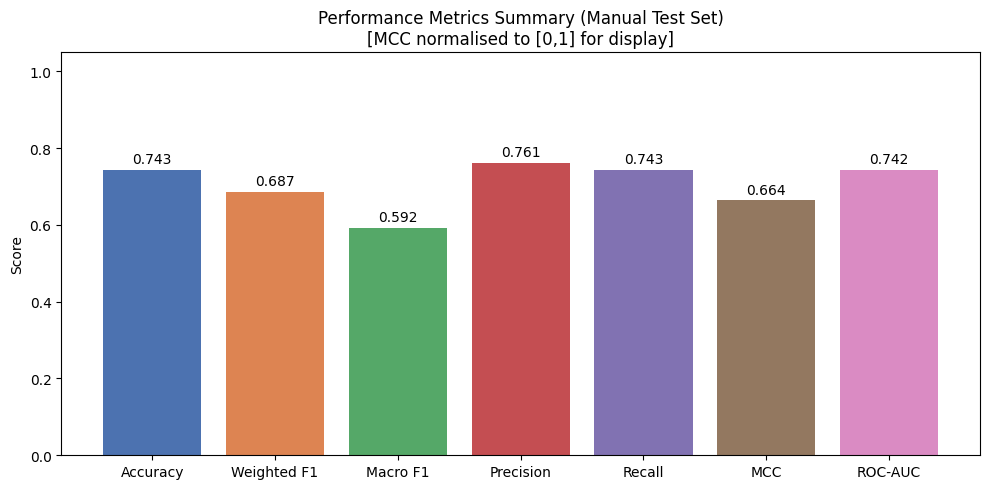

In [16]:
# ============================================================
# BLOCK 14: Metrics Summary Bar Chart
# ============================================================

metrics = {
    "Accuracy"   : acc,
    "Weighted F1": f1_w,
    "Macro F1"   : f1_m,
    "Precision"  : prec,
    "Recall"     : rec,
    "MCC"        : (mcc + 1) / 2,   # normalise MCC to [0,1] for display
    "ROC-AUC"    : auc,
}

names  = list(metrics.keys())
values = list(metrics.values())

plt.figure(figsize=(10, 5))
bars = plt.bar(names, values, color=["#4C72B0", "#DD8452", "#55A868",
                                      "#C44E52", "#8172B2", "#937860", "#DA8BC3"])
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Performance Metrics Summary (Manual Test Set)\n[MCC normalised to [0,1] for display]")
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f"{val:.3f}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

Using Colab cache for faster access to the 'english-translation-error-detection-dataset' dataset.


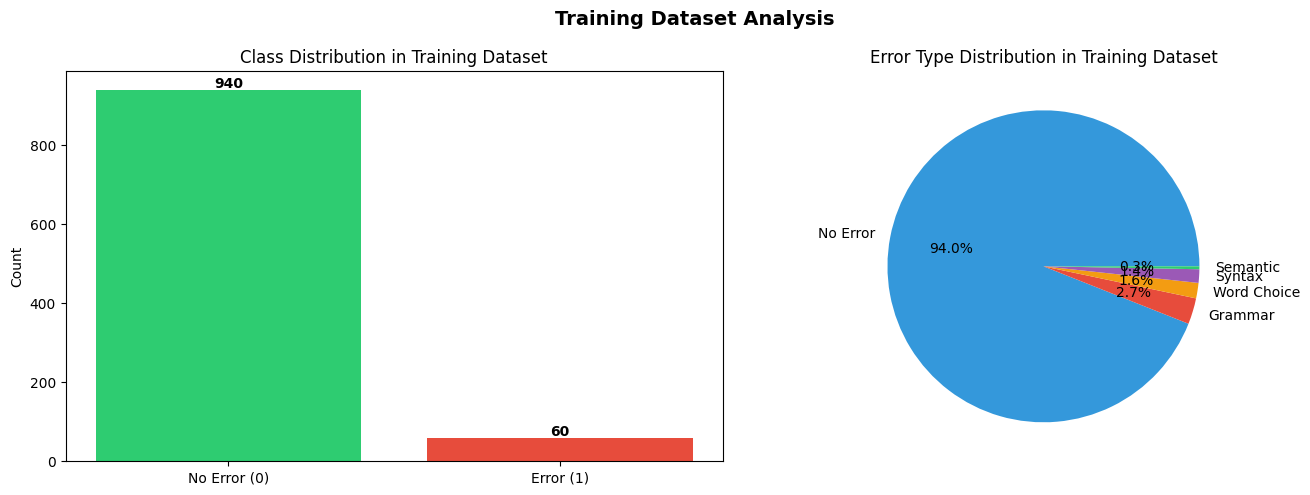


Error Type Counts:
Error_Type
No Error       940
Grammar         27
Word Choice     16
Syntax          14
Semantic         3


In [17]:
# ============================================================
# BLOCK 15: Error-Type Breakdown on Training Dataset
# ============================================================

# Re-download dataset to get full columns (if df was slimmed earlier)
import kagglehub, os
path = kagglehub.dataset_download("zara2099/english-translation-error-detection-dataset")
csv_file = [f for f in os.listdir(path) if f.endswith(".csv")][0]
df_full = pd.read_csv(os.path.join(path, csv_file))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
class_counts = df_full["Error_Flag"].value_counts()
axes[0].bar(["No Error (0)", "Error (1)"], class_counts.values, color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Class Distribution in Training Dataset")
axes[0].set_ylabel("Count")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

# Error type breakdown
error_type_counts = df_full["Error_Type"].value_counts(dropna=False)
error_type_counts.index = error_type_counts.index.fillna("No Error")
axes[1].pie(error_type_counts.values,
            labels=error_type_counts.index,
            autopct="%1.1f%%",
            colors=["#3498db", "#e74c3c", "#f39c12", "#9b59b6", "#2ecc71"])
axes[1].set_title("Error Type Distribution in Training Dataset")

plt.suptitle("Training Dataset Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nError Type Counts:")
print(error_type_counts.to_string())

/tmp/ipykernel_4955/42578785.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_to_plot, labels=["No Error", "Error"], patch_artist=True)


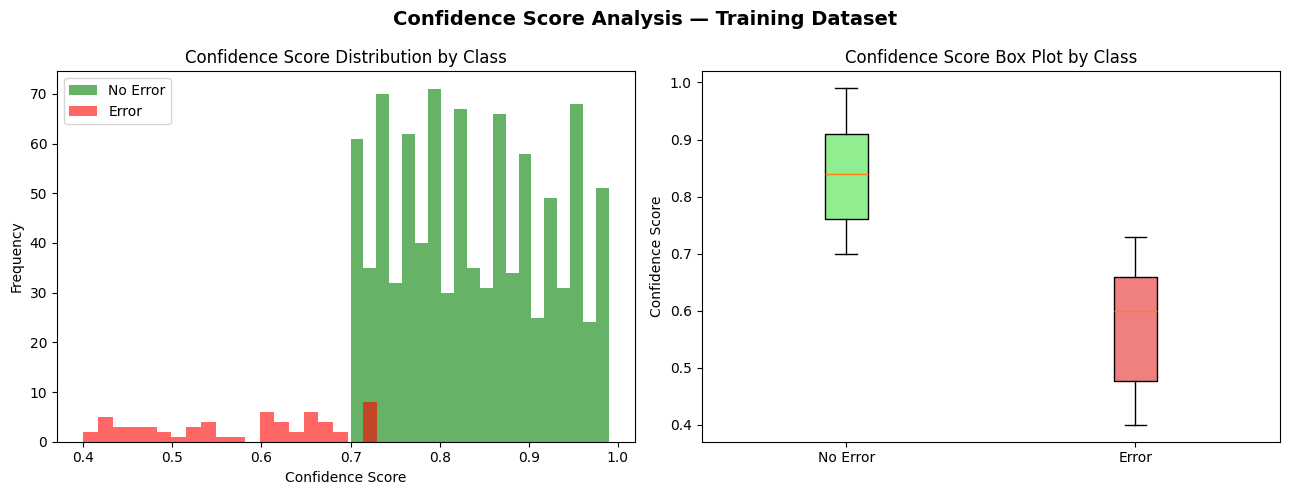

In [18]:
# ============================================================
# BLOCK 16: Confidence Score Distribution by Error Flag
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confidence score histogram by class
for flag, color, label in [(0, "green", "No Error"), (1, "red", "Error")]:
    subset = df_full[df_full["Error_Flag"] == flag]["Confidence_Score"]
    axes[0].hist(subset, bins=20, alpha=0.6, color=color, label=label)
axes[0].set_xlabel("Confidence Score")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Confidence Score Distribution by Class")
axes[0].legend()

# Box plot
import matplotlib.patches as mpatches
data_to_plot = [
    df_full[df_full["Error_Flag"] == 0]["Confidence_Score"].dropna().values,
    df_full[df_full["Error_Flag"] == 1]["Confidence_Score"].dropna().values,
]
bp = axes[1].boxplot(data_to_plot, labels=["No Error", "Error"], patch_artist=True)
bp["boxes"][0].set_facecolor("lightgreen")
bp["boxes"][1].set_facecolor("lightcoral")
axes[1].set_title("Confidence Score Box Plot by Class")
axes[1].set_ylabel("Confidence Score")

plt.suptitle("Confidence Score Analysis — Training Dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# BLOCK 16: Custom Input Prediction Cell
# ============================================================
import torch
import torch.nn.functional as F

model.eval()
labels = ["No Error", "Error"]

def predict_sentence(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        logits, _ = model(inputs["input_ids"], inputs["attention_mask"])
        probs = F.softmax(logits, dim=1)
        confidence, pred_class = torch.max(probs, dim=1)

    return labels[pred_class.item()], confidence.item()

text = input("Enter a sentence: ")
prediction, confidence = predict_sentence(text)

print("\nPrediction:", prediction)
print("Confidence:", round(confidence * 100, 2), "%")